# E-Commerce Sales & Customer Analysis

### Python Data Analytics Project

**Objective:** Analyze e-commerce transaction data to identify sales trends, profitability drivers, regional performance, product-level losses, and discount-related profitability patterns.

**Tools:** Python | Pandas | NumPy | Matplotlib | Seaborn | Jupyter

## 1. Project Objective

This analysis explores e-commerce transaction data to answer key business questions:

- Which categories and products drive sales and profit?
- Which regions and customer segments perform best?
- Where are profitability problems occurring?
- How are discounts associated with profit?
- How have sales and profit changed over time?
- What business actions can be taken based on the findings?

In [44]:
import pandas as pd

In [45]:
df = pd.read_csv("data/Ecommerce.csv")

In [46]:
df.head()

,Row ID,Order ID,order date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Discount,Profit,Order Year,Order Month,Month Number,Quarter,Profit Status,Discount Category,Order Size,Profit Margin %
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,41.9136,2016,August,8,Q3,Profit,No Discount,Medium,0.1600
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0.00,219.5820,2016,August,8,Q3,Profit,No Discount,Large,0.3000
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,0.00,6.8714,2016,December,12,Q4,Profit,No Discount,Small,0.4700
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.45,-383.0310,2015,November,11,Q4,Loss,Medium,Large,-0.4000
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0.20,2.5164,2015,November,11,Q4,Profit,Low,Small,0.1125


In [47]:
df.shape

(9994, 29)

In [48]:
df.columns

Index(['Row ID', 'Order ID', 'order date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Order Year',
       'Order Month', 'Month Number', 'Quarter', 'Profit Status',
       'Discount Category', 'Order Size', 'Profit Margin %'],
      dtype='str')

In [49]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Row ID             9994 non-null   int64  
 1   Order ID           9994 non-null   str    
 2   order date         9994 non-null   str    
 3   Ship Date          9994 non-null   str    
 4   Ship Mode          9994 non-null   str    
 5   Customer ID        9994 non-null   str    
 6   Customer Name      9994 non-null   str    
 7   Segment            9994 non-null   str    
 8   Country            9994 non-null   str    
 9   City               9994 non-null   str    
 10  State              9994 non-null   str    
 11  Postal Code        9994 non-null   int64  
 12  Region             9994 non-null   str    
 13  Product ID         9994 non-null   str    
 14  Category           9994 non-null   str    
 15  Sub-Category       9994 non-null   str    
 16  Product Name       9994 non-null   

In [50]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 29 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Row ID             9994 non-null   int64  
 1   Order ID           9994 non-null   str    
 2   order date         9994 non-null   str    
 3   Ship Date          9994 non-null   str    
 4   Ship Mode          9994 non-null   str    
 5   Customer ID        9994 non-null   str    
 6   Customer Name      9994 non-null   str    
 7   Segment            9994 non-null   str    
 8   Country            9994 non-null   str    
 9   City               9994 non-null   str    
 10  State              9994 non-null   str    
 11  Postal Code        9994 non-null   int64  
 12  Region             9994 non-null   str    
 13  Product ID         9994 non-null   str    
 14  Category           9994 non-null   str    
 15  Sub-Category       9994 non-null   str    
 16  Product Name       9994 non-null   

In [51]:
df[["order date", "Ship Date"]].dtypes

order date    str
Ship Date     str
dtype: object

In [52]:
df.duplicated().sum()

np.int64(0)

In [53]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit,Order Year,Month Number,Profit Margin %
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,7.174605,0.120314
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,3.428273,0.466754
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,1.000000,-2.750000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,4.000000,0.075000
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,8.000000,0.270000
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,10.000000,0.362500
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,12.000000,0.500000


In [54]:
print("Categories:", df["Category"].unique())
print("Sub-Categories:", df["Sub-Category"].nunique())
print("Regions:", df["Region"].unique())
print("Segments:", df["Segment"].unique())

Categories: <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
Sub-Categories: 17
Regions: <StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str
Segments: <StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str


In [55]:
print("First order date:", df["order date"].min())
print("Last order date:", df["order date"].max())

First order date: 01-01-2017
Last order date: 9/30/2017


In [56]:
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Quantity:", df["Quantity"].sum())
print("Average Sales per Order:", df["Sales"].mean())
print("Average Profit per Order:", df["Profit"].mean())

Total Sales: 2297200.8603
Total Profit: 286397.0217
Total Quantity: 37873
Average Sales per Order: 229.85800083049827
Average Profit per Order: 28.65689630778467


In [57]:
profit_margin = (df["Profit"].sum() / df["Sales"].sum()) * 100

print("Overall Profit Margin:", round(profit_margin, 2), "%")

Overall Profit Margin: 12.47 %


In [58]:
category_analysis = df.groupby("Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

category_analysis["Profit Margin %"] = (
    category_analysis["Profit"] / category_analysis["Sales"] * 100
)

category_analysis.sort_values("Sales", ascending=False)

,Sales,Profit,Quantity,Profit Margin %
Category,,,,
Technology,836154.0330,145454.9481,6939,17.395712
Furniture,741999.7953,18451.2728,8028,2.486695
Office Supplies,719047.0320,122490.8008,22906,17.035158


In [59]:
furniture_analysis = df[df["Category"] == "Furniture"].groupby("Sub-Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

furniture_analysis["Profit Margin %"] = (
    furniture_analysis["Profit"] / furniture_analysis["Sales"] * 100
)

furniture_analysis.sort_values("Profit Margin %")

,Sales,Profit,Quantity,Profit Margin %
Sub-Category,,,,
Tables,206965.5320,-17725.4811,1241,-8.564460
Bookcases,114879.9963,-3472.5560,868,-3.022768
Chairs,328449.1030,26590.1663,2356,8.095673
Furnishings,91705.1640,13059.1436,3563,14.240358


In [60]:
discount_analysis = df[df["Category"] == "Furniture"].groupby("Sub-Category").agg(
    Avg_Discount=("Discount", "mean"),
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

discount_analysis["Profit Margin %"] = (
    discount_analysis["Profit"] / discount_analysis["Sales"] * 100
)

discount_analysis.sort_values("Avg_Discount", ascending=False)

,Avg_Discount,Sales,Profit,Profit Margin %
Sub-Category,,,,
Tables,0.261285,206965.5320,-17725.4811,-8.564460
Bookcases,0.211140,114879.9963,-3472.5560,-3.022768
Chairs,0.170178,328449.1030,26590.1663,8.095673
Furnishings,0.138349,91705.1640,13059.1436,14.240358


In [61]:
discount_profit = df.groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

discount_profit["Profit Margin %"] = (
    discount_profit["Profit"] / discount_profit["Sales"] * 100
)

discount_profit

,Sales,Profit,Quantity,Profit Margin %
Discount,,,,
0.00,1.087908e+06,320987.6032,18267,29.505019
0.10,5.436935e+04,9029.1770,373,16.607108
0.15,2.755852e+04,1418.9915,198,5.149012
0.20,7.645944e+05,90337.3060,13660,11.815063
0.30,1.032267e+05,-10369.2774,849,-10.045155
0.32,1.449346e+04,-2391.1377,105,-16.498047
0.40,1.164178e+05,-23057.0504,786,-19.805437
0.45,5.484974e+03,-2493.1111,45,-45.453472
0.50,5.891854e+04,-20506.4281,241,-34.804712


In [62]:
product_analysis = df.groupby("Product Name").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

product_analysis.sort_values("Profit").head(10)

,Sales,Profit,Quantity
Product Name,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22
Balt Solid Wood Round Tables,6518.754,-1201.0581,19


In [63]:
loss_products = df.groupby("Product Name").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Avg_Discount=("Discount", "mean"),
    Quantity=("Quantity", "sum")
)

loss_products.sort_values("Profit").head(10)

,Sales,Profit,Avg_Discount,Quantity
Product Name,,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,0.533333,9
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,0.400000,18
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,0.500000,4
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,0.280000,27
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,0.350000,33
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,0.450000,27
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,0.500000,6
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,0.100000,22
Balt Solid Wood Round Tables,6518.754,-1201.0581,0.200000,19


In [64]:
region_analysis = df.groupby("Region").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

region_analysis["Profit Margin %"] = (
    region_analysis["Profit"] / region_analysis["Sales"] * 100
)

region_analysis.sort_values("Sales", ascending=False)

,Sales,Profit,Quantity,Profit Margin %
Region,,,,
West,725457.8245,108418.4489,12266,14.944831
East,678781.2400,91522.7800,10618,13.483399
Central,501239.8908,39706.3625,8780,7.921629
South,391721.9050,46749.4303,6209,11.934342


In [65]:
region_category = df.groupby(["Region", "Category"]).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

region_category["Profit Margin %"] = (
    region_category["Profit"] / region_category["Sales"] * 100
)

region_category

Sales      Profit  Profit Margin %
Region  Category                                                 
Central Furniture        163797.1638  -2871.0494        -1.752808
        Office Supplies  167026.4150   8879.9799         5.316512
        Technology       170416.3120  33697.4320        19.773595
East    Furniture        208291.2040   3046.1658         1.462455
        Office Supplies  205516.0550  41014.5791        19.956873
        Technology       264973.9810  47462.0351        17.911961
South   Furniture        117298.6840   6771.2061         5.772619
        Office Supplies  125651.3130  19986.3928        15.906235
        Technology       148771.9080  19991.8314        13.437908
West    Furniture        252612.7435  11504.9503         4.554382
        Office Supplies  220853.2490  52609.8490        23.821180
        Technology       251991.8320  44303.6496        17.581383

In [66]:
central_furniture = df[
    (df["Region"] == "Central") &
    (df["Category"] == "Furniture")
].groupby("Sub-Category").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Avg_Discount=("Discount", "mean"),
    Quantity=("Quantity", "sum")
)

central_furniture["Profit Margin %"] = (
    central_furniture["Profit"] / central_furniture["Sales"] * 100
)

central_furniture.sort_values("Profit")

,Sales,Profit,Avg_Discount,Quantity,Profit Margin %
Sub-Category,,,,,
Furnishings,15254.3700,-3906.2168,0.403902,758,-25.607198
Tables,39154.9710,-3559.6504,0.262500,262,-9.091184
Bookcases,24157.1768,-1997.9043,0.232800,192,-8.270438
Chairs,85230.6460,6592.7221,0.192857,615,7.735154


In [67]:
central_furnishings_products = df[
    (df["Region"] == "Central") &
    (df["Sub-Category"] == "Furnishings")
].groupby("Product Name").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Avg_Discount=("Discount", "mean"),
    Quantity=("Quantity", "sum")
)

central_furnishings_products.sort_values("Profit").head(10)

,Sales,Profit,Avg_Discount,Quantity
Product Name,,,,
"Tenex Chairmat w/ Average Lip, 45"" x 53""",544.896,-681.1200,0.6,9
Tenex Antistatic Computer Chair Mats,341.960,-427.4500,0.6,5
"Deflect-o RollaMat Studded, Beveled Mat for Medium Pile Carpeting",405.812,-426.1026,0.6,11
Luxo Professional Fluorescent Magnifier Lamp with Clamp-Mount Base,419.680,-356.7280,0.6,5
Eldon ClusterMat Chair Mat with Cordless Antistatic Protection,800.624,-252.0146,0.2,13
"Tenex Carpeted, Granite-Look or Clear Contemporary Contour Shape Chair Mats",410.118,-247.4850,0.4,10
"Tenex ""The Solids"" Textured Chair Mats",223.872,-240.6624,0.6,8
"Rubbermaid ClusterMat Chairmats, Mat Size- 66"" x 60"", Lip 20"" x 11"" -90 Degree Angle",599.292,-239.7168,0.3,9
Eldon Cleatmat Plus Chair Mats for High Pile Carpets,159.040,-194.8240,0.6,5


In [68]:
central_furnishings_discount = df[
    (df["Region"] == "Central") &
    (df["Sub-Category"] == "Furnishings")
].groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

central_furnishings_discount["Profit Margin %"] = (
    central_furnishings_discount["Profit"] /
    central_furnishings_discount["Sales"] * 100
)

central_furnishings_discount

,Sales,Profit,Quantity,Profit Margin %
Discount,,,,
0.0,8609.67,2038.4384,257,23.676150
0.6,6644.70,-5944.6552,501,-89.464614


In [69]:
segment_analysis = df.groupby("Segment").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

segment_analysis["Profit Margin %"] = (
    segment_analysis["Profit"] /
    segment_analysis["Sales"] * 100
)

segment_analysis.sort_values("Sales", ascending=False)

,Sales,Profit,Quantity,Profit Margin %
Segment,,,,
Consumer,1.161401e+06,134119.2092,19521,11.548050
Corporate,7.061464e+05,91979.1340,11608,13.025506
Home Office,4.296531e+05,60298.6785,6744,14.034269


In [70]:
segment_category = df.groupby(["Segment", "Category"]).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
)

segment_category["Profit Margin %"] = (
    segment_category["Profit"] /
    segment_category["Sales"] * 100
)

segment_category

Sales      Profit  Profit Margin %
Segment     Category                                                 
Consumer    Furniture        391049.3120   6991.0786         1.787774
            Office Supplies  363952.1360  56330.3210        15.477398
            Technology       406399.8970  70797.8096        17.420725
Corporate   Furniture        229019.7858   7584.8158         3.311860
            Office Supplies  230676.4620  40227.3202        17.438849
            Technology       246450.1190  44166.9980        17.921273
Home Office Furniture        121930.6975   3875.3784         3.178345
            Office Supplies  124418.4340  25933.1596        20.843503
            Technology       183304.0170  30490.1405        16.633646

In [71]:
monthly_analysis = df.groupby(
    ["Order Year", "Month Number", "Order Month"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).reset_index()

monthly_analysis = monthly_analysis.sort_values(
    ["Order Year", "Month Number"]
)

monthly_analysis

,Order Year,Month Number,Order Month,Sales,Profit
0,2014,1,January,28953.7060,4549.4546
1,2014,2,February,12743.1080,2654.5569
2,2014,3,March,54801.9060,92.6990
3,2014,4,April,24710.0160,4601.0714
4,2014,5,May,29639.8340,3912.2499
5,2014,6,June,29287.0306,4499.7446
6,2014,7,July,35341.2460,-1783.5425
7,2014,8,August,37854.5475,2081.2676
8,2014,9,September,66110.2238,10232.2626
9,2014,10,October,34561.9470,4075.1499


In [72]:
monthly_analysis = df.groupby(
    ["Order Year", "Month Number", "Order Month"]
).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).reset_index()

monthly_analysis = monthly_analysis.sort_values(
    ["Order Year", "Month Number"]
)

monthly_analysis

,Order Year,Month Number,Order Month,Sales,Profit
0,2014,1,January,28953.7060,4549.4546
1,2014,2,February,12743.1080,2654.5569
2,2014,3,March,54801.9060,92.6990
3,2014,4,April,24710.0160,4601.0714
4,2014,5,May,29639.8340,3912.2499
5,2014,6,June,29287.0306,4499.7446
6,2014,7,July,35341.2460,-1783.5425
7,2014,8,August,37854.5475,2081.2676
8,2014,9,September,66110.2238,10232.2626
9,2014,10,October,34561.9470,4075.1499


In [73]:
monthly_analysis = df.groupby(["Order Year", "Month Number", "Order Month"]).agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum")
).reset_index()

monthly_analysis = monthly_analysis.sort_values(
    ["Order Year", "Month Number"]
)

monthly_analysis

,Order Year,Month Number,Order Month,Sales,Profit
0,2014,1,January,28953.7060,4549.4546
1,2014,2,February,12743.1080,2654.5569
2,2014,3,March,54801.9060,92.6990
3,2014,4,April,24710.0160,4601.0714
4,2014,5,May,29639.8340,3912.2499
5,2014,6,June,29287.0306,4499.7446
6,2014,7,July,35341.2460,-1783.5425
7,2014,8,August,37854.5475,2081.2676
8,2014,9,September,66110.2238,10232.2626
9,2014,10,October,34561.9470,4075.1499


In [74]:
yearly_analysis = df.groupby("Order Year").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

yearly_analysis["Profit Margin %"] = (
    yearly_analysis["Profit"] /
    yearly_analysis["Sales"] * 100
)

yearly_analysis

,Sales,Profit,Quantity,Profit Margin %
Order Year,,,,
2014,484247.4981,49543.9741,7581,10.231126
2015,470532.5090,61618.6037,7979,13.095504
2016,609205.5980,81795.1743,9837,13.426530
2017,733215.2552,93439.2696,12476,12.743771


In [75]:
yearly_growth = yearly_analysis.copy()

yearly_growth["Sales Growth %"] = (
    yearly_growth["Sales"].pct_change() * 100
)

yearly_growth["Profit Growth %"] = (
    yearly_growth["Profit"].pct_change() * 100
)

yearly_growth.round(2)

,Sales,Profit,Quantity,Profit Margin %,Sales Growth %,Profit Growth %
Order Year,,,,,,
2014,484247.50,49543.97,7581,10.23,NaN,NaN
2015,470532.51,61618.60,7979,13.10,-2.83,24.37
2016,609205.60,81795.17,9837,13.43,29.47,32.74
2017,733215.26,93439.27,12476,12.74,20.36,14.24


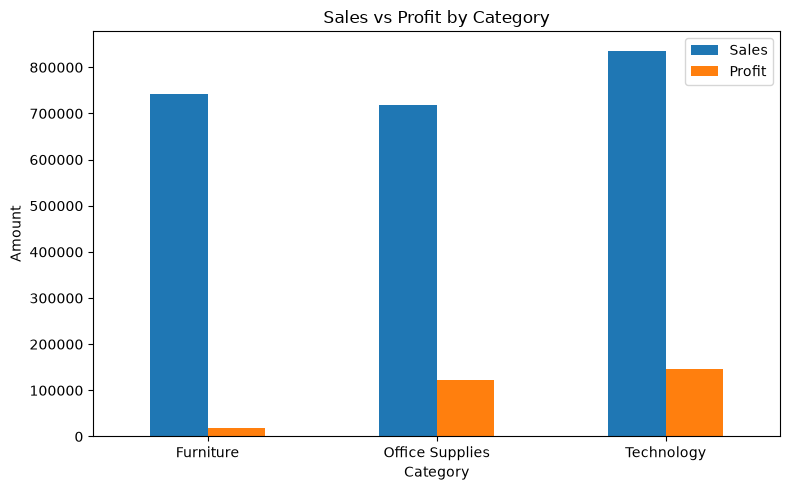

In [76]:

import matplotlib.pyplot as plt

category_analysis[["Sales", "Profit"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales vs Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

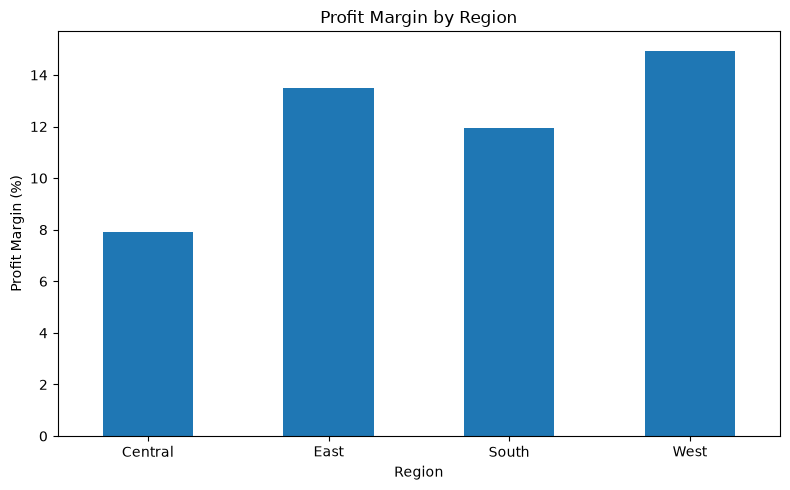

In [77]:
region_analysis["Profit Margin %"].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Profit Margin by Region")
plt.xlabel("Region")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

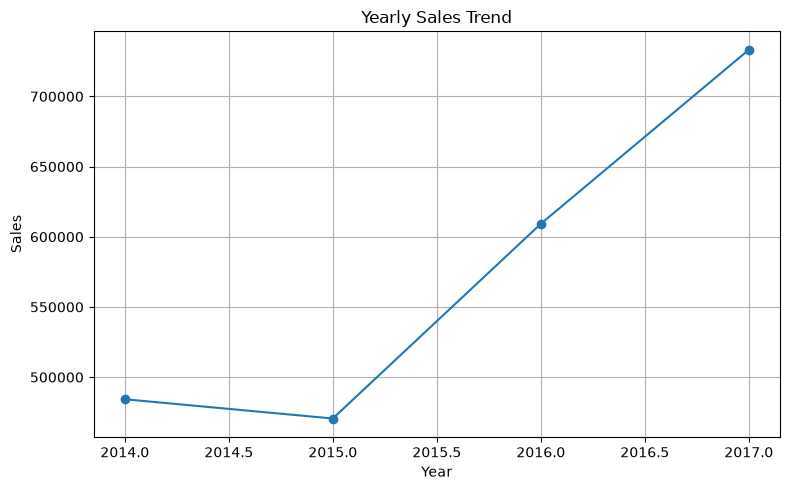

In [78]:
yearly_analysis["Sales"].plot(
    kind="line",
    marker="o",
    figsize=(8, 5)
)

plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

In [79]:
discount_profit = df.groupby("Discount").agg(
    Sales=("Sales", "sum"),
    Profit=("Profit", "sum"),
    Quantity=("Quantity", "sum")
)

discount_profit["Profit Margin %"] = (
    discount_profit["Profit"] / discount_profit["Sales"] * 100
)

discount_profit

,Sales,Profit,Quantity,Profit Margin %
Discount,,,,
0.00,1.087908e+06,320987.6032,18267,29.505019
0.10,5.436935e+04,9029.1770,373,16.607108
0.15,2.755852e+04,1418.9915,198,5.149012
0.20,7.645944e+05,90337.3060,13660,11.815063
0.30,1.032267e+05,-10369.2774,849,-10.045155
0.32,1.449346e+04,-2391.1377,105,-16.498047
0.40,1.164178e+05,-23057.0504,786,-19.805437
0.45,5.484974e+03,-2493.1111,45,-45.453472
0.50,5.891854e+04,-20506.4281,241,-34.804712


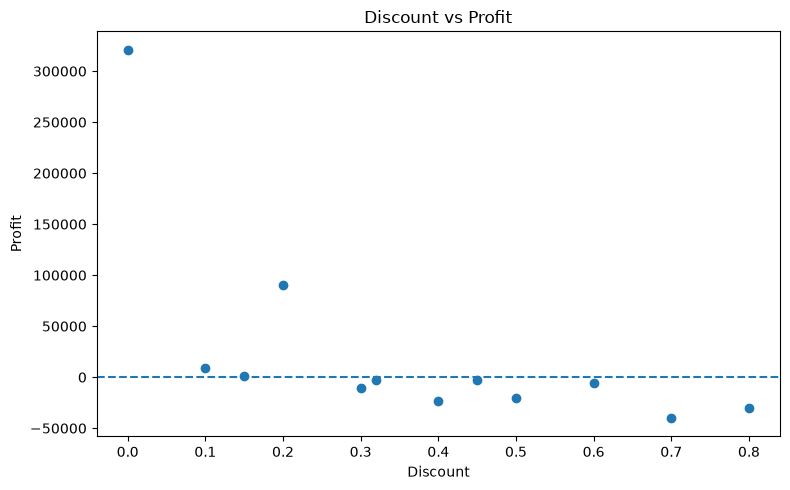

In [80]:
plt.figure(figsize=(8, 5))

plt.scatter(
    discount_profit.index,
    discount_profit["Profit"]
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.axhline(0, linestyle="--")

plt.tight_layout()
plt.show()

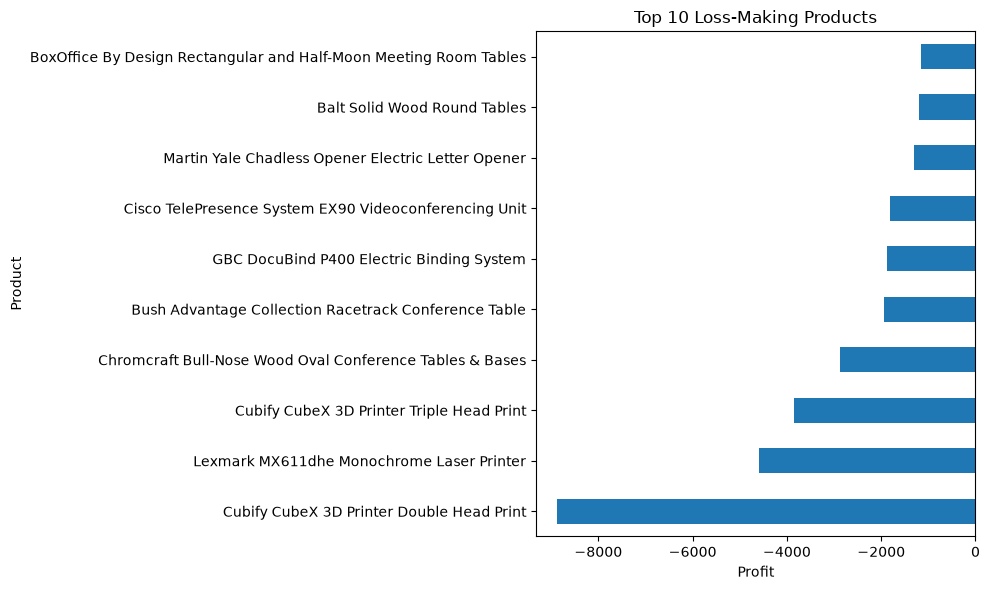

In [81]:
top_loss_products = product_analysis.sort_values(
    "Profit"
).head(10)

top_loss_products["Profit"].plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Top 10 Loss-Making Products")
plt.xlabel("Profit")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## Key Business Insights

1. Technology generated the highest sales and profit, with a strong profit margin of approximately 17.4%.

2. Furniture generated substantial sales but had a much lower profit margin of approximately 2.5%, indicating a profitability concern.

3. Within Furniture, Tables and Bookcases were loss-making, while Chairs and Furnishings remained profitable overall.

4. Higher discount levels were associated with lower profitability. At discounts of 30% or higher, several discount groups showed negative profit.

5. The Central region had the lowest overall profit margin at approximately 7.9%, compared with approximately 13–15% in the other regions.

6. Central Furniture was a major contributor to the region's lower profitability, with a negative overall profit margin.

7. Sales increased strongly from 2015 to 2017, reaching approximately 733K in 2017. However, profit grew more slowly than sales in 2017, causing the profit margin to decline from 13.43% in 2016 to 12.74%.

8. Several individual products generated significant losses, showing that category-level performance can hide product-level profitability problems.

## Business Recommendations

1. **Review high-discount products**
   - Investigate products with discounts of 30% or more.
   - Test lower discount levels where commercially feasible.
   - Monitor profit margin alongside sales volume before changing discount policies.

2. **Improve Furniture profitability**
   - Review pricing, discounts, and costs for Tables and Bookcases.
   - Identify whether selected products should be repriced, promoted differently, or discontinued.

3. **Investigate Central region**
   - Perform a deeper review of Central-region Furniture.
   - Focus on products and discount levels contributing to negative margins.

4. **Monitor product-level profitability**
   - Track products with recurring negative profit.
   - Review pricing, discounting, and product costs before increasing sales volume.

5. **Balance revenue growth with profitability**
   - Continue monitoring sales growth, but evaluate profit margin alongside revenue.
   - The 2017 results show that strong sales growth can occur while profit margin decreases.

6. **Use targeted promotions**
   - Focus promotions on products and customer segments that maintain healthy margins.
   - Avoid relying only on sales volume when evaluating promotional performance.